#  **Week 5 | Introduction to Classification**

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [2]:
train = pd.read_csv('DATASETS/Iris.csv')
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Exploratory Data Analysis

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
d = train.describe()
d

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


C:\Users\USER\AppData\Local\Temp\ipykernel_20112\3566202629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species',data=train,palette='RdBu_r')


<Axes: xlabel='Species', ylabel='count'>

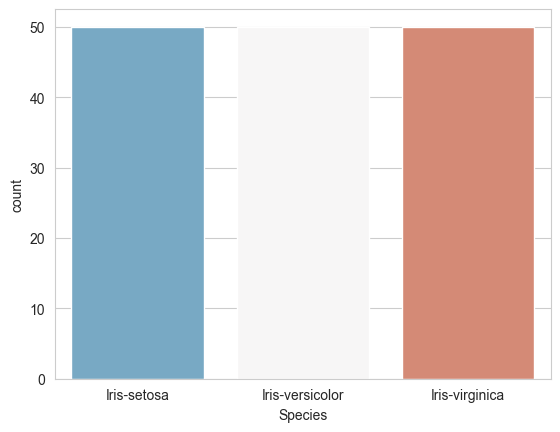

In [6]:
# Cek relative size dari survived dan not survived
sns.set_style('whitegrid')
sns.countplot(x='Species',data=train,palette='RdBu_r')

Dari visualisasi data terlampir, distribusi data pada kelas Species (Iris-setosa, Iris-versicolor dan Iris-virginica) memiliki nilai yang sama dan seimbang.


<Axes: xlabel='Survived', ylabel='count'>

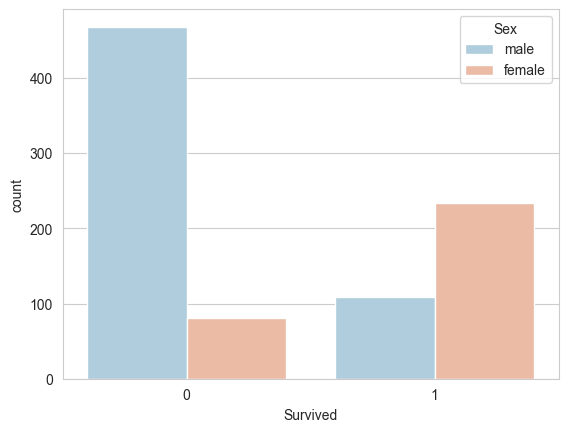

In [6]:
# Survivablity vs sex
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Sex',data=train,palette='RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

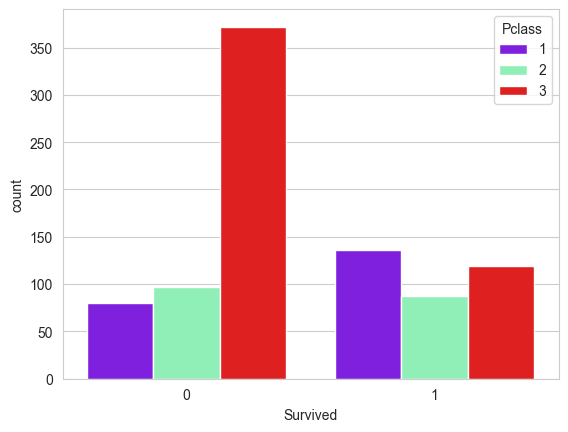

In [7]:
# Survivablity vs passenger class
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass',data=train,palette='rainbow')

Text(0.5, 1.0, 'Persentase penumpang yang selamat berdasarkan kelas')

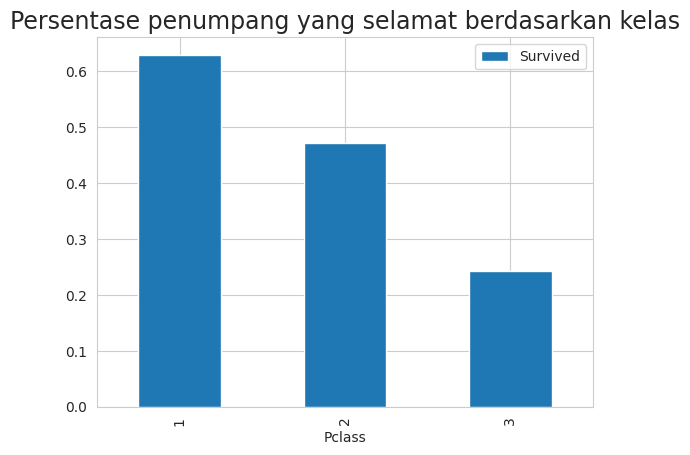

In [ ]:
f_class_survived=train.groupby('Pclass')['Survived'].mean()
f_class_survived = pd.DataFrame(f_class_survived)
f_class_survived
f_class_survived.plot.bar(y='Survived')
plt.title("Persentase penumpang yang selamat berdasarkan kelas",fontsize=17)

<Axes: xlabel='Survived', ylabel='count'>

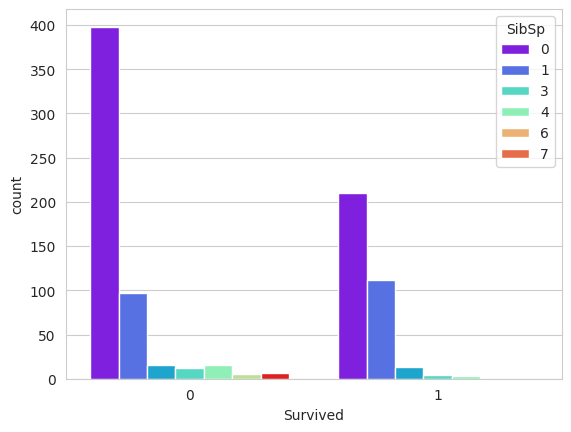

In [ ]:
# Survived vs Sibling and Spouses
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='SibSp',data=train,palette='rainbow')

<Axes: title={'center': 'Histogram usia penumpang'}, xlabel='Usia penumpang', ylabel='Count'>

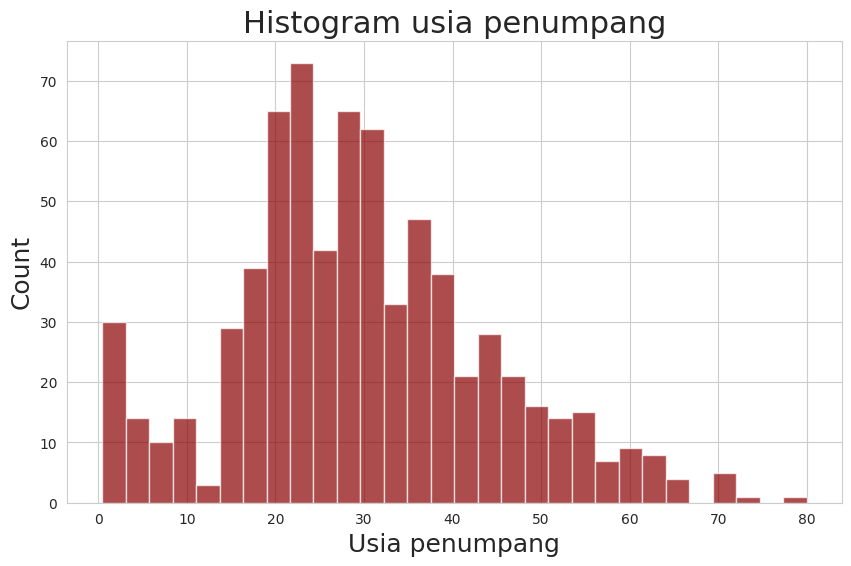

In [ ]:
# Cek distribusi dari umur
plt.xlabel("Usia penumpang",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram usia penumpang",fontsize=22)
train['Age'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

<ipython-input-15-1bb3acdf5dc3>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass',y='Age',data=train,palette='winter')


<Axes: xlabel='Passenger Class', ylabel='Age'>

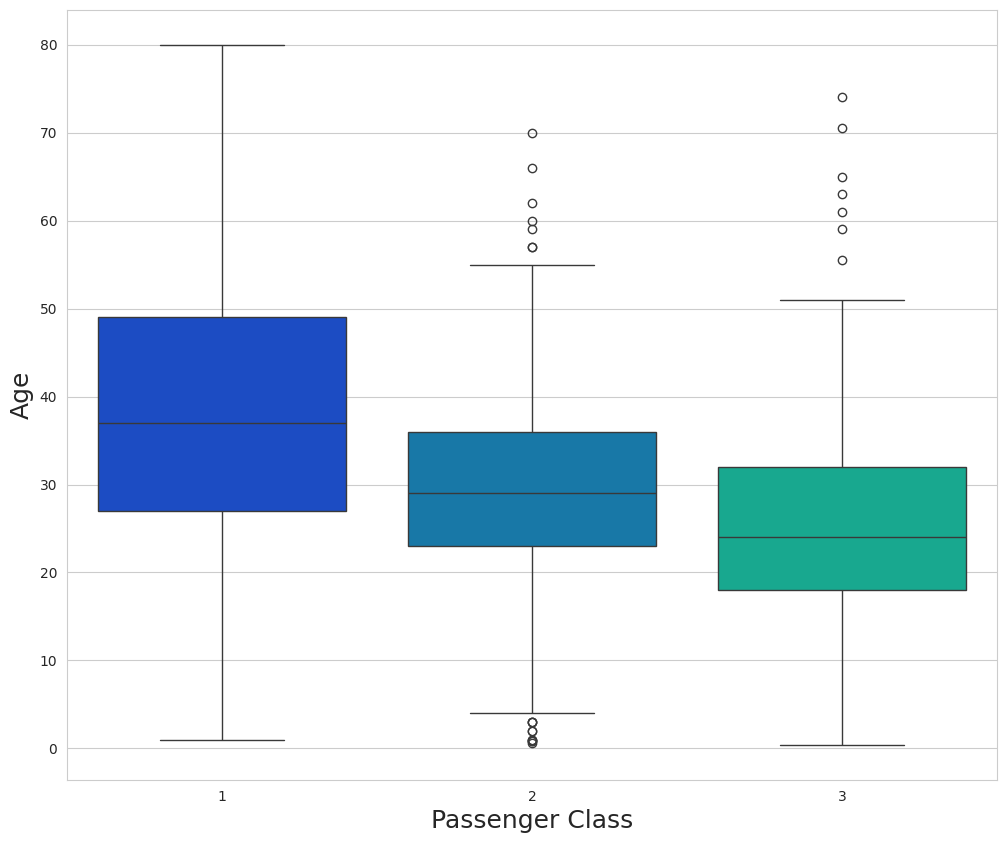

In [ ]:
# Distribusi umur di setiap kelas
plt.figure(figsize=(12, 10))
plt.xlabel("Passenger Class",fontsize=18)
plt.ylabel("Age",fontsize=18)
sns.boxplot(x='Pclass',y='Age',data=train,palette='winter')

Text(0.5, 0, 'Passenger class')

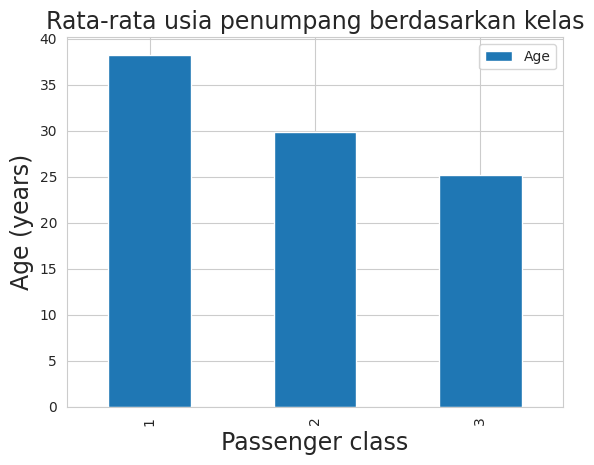

In [ ]:
f_class_Age=train.groupby('Pclass')['Age'].mean()
f_class_Age = pd.DataFrame(f_class_Age)
f_class_Age.plot.bar(y='Age')
plt.title("Rata-rata usia penumpang berdasarkan kelas",fontsize=17)
plt.ylabel("Age (years)", fontsize=17)
plt.xlabel("Passenger class", fontsize=17)

### Fitur Engineering

In [ ]:
a=list(f_class_Age['Age'])

def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return a[0]

        elif Pclass == 2:
            return a[1]

        else:
            return a[2]

    else:
        return Age

In [ ]:
train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)

<ipython-input-17-7d5da24aec80>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
<ipython-input-17-7d5da24aec80>:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

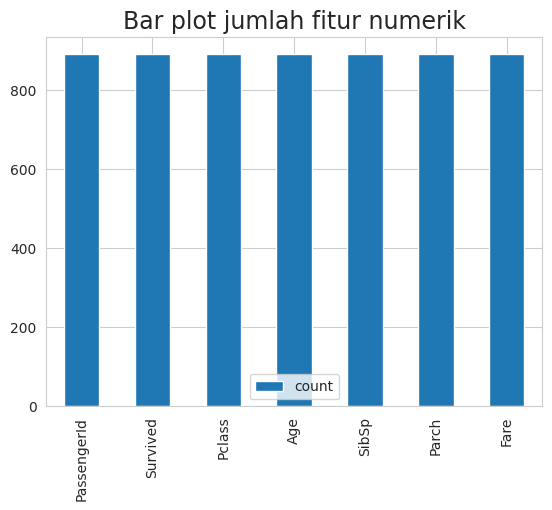

In [ ]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [ ]:
# drop cabin karena memiliki banyak null value (>50%)
train.drop('Cabin',axis=1,inplace=True)
train.dropna(inplace=True)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
# Drop semua kolom yang tidak penting
train.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Sex'] = le.fit_transform(train['Sex'])
train['Embarked'] = le.fit_transform(train['Embarked'])
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


### Training

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1),
                                                    train['Survived'], test_size=0.30,
                                                    random_state=42)

In [ ]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (622, 7)
Test shape: (267, 7)


# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = clf1.predict(X_test)

### Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.71
Confusion Matrix:
[[136  31]
 [ 47  53]]
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.81      0.78       167
           1       0.63      0.53      0.58       100

    accuracy                           0.71       267
   macro avg       0.69      0.67      0.68       267
weighted avg       0.70      0.71      0.70       267



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [ ]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 0.71
Confusion Matrix:
[[136  31]
 [ 46  54]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       167
           1       0.64      0.54      0.58       100

    accuracy                           0.71       267
   macro avg       0.69      0.68      0.68       267
weighted avg       0.71      0.71      0.71       267



### jika ingin mencoba semua parameter

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.730026   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.731548   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.720310   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.717110   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.713884   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.713845   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.709006   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.710632   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.704219   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.705819   
2   {'metric': 'euclidean', 'n_neighbors

In [ ]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [ ]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [ ]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.72
Presisi:  0.70
Recall:   0.69
F1-Score: 0.69

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       167
           1       0.65      0.55      0.60       100

    accuracy                           0.72       267
   macro avg       0.70      0.69      0.69       267
weighted avg       0.72      0.72      0.72       267

Confusion Matrix:
[[138  29]
 [ 45  55]]


In [ ]:
import numpy as np

# Data penumpang baru (dalam urutan sama seperti fitur model)
new_data = np.array([[3, 0, 25.0, 0, 0, 7.25, 2]])

# Prediksi apakah penumpang ini selamat atau tidak
prediction = best_model.predict(new_data)

print("Prediksi (0 = Tidak Selamat, 1 = Selamat):", prediction[0])

Prediksi (0 = Tidak Selamat, 1 = Selamat): 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
